# Phase 2 - Analyse exploratoire (EDA) du jeu CICIDS2017

Detection explicable d'anomalies reseau.
Ce notebook charge le dataset gele (parquet propre), explore la
repartition des classes, le desequilibre binaire BENIGN/attaque, les
correlations entre features de flux, les distributions de quelques
features discriminantes et les signatures de chaque famille d'attaque.
Chaque figure est sauvegardee en PNG dans reports/figures.

## 1. Imports et configuration

In [1]:
# 1. Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chemin absolu de la racine du projet
BASE = "/home/samouraifox/Work/stuff/S6/Notes_Ai/projet-final/model-building/Detection-explicable-danomalies"

# Dossier de sortie des figures
DOSSIER_FIGURES = BASE + "/reports/figures"
os.makedirs(DOSSIER_FIGURES, exist_ok=True)

# Style global seaborn
sns.set(style="whitegrid")

## 2. Chargement du dataset gele

On charge le parquet propre (2 520 798 lignes, 78 features numeriques
+ Label + Label_binary + Label_group).

In [2]:
# 2. Chargement du dataset propre au format parquet
df = pd.read_parquet(BASE + "/data/processed/cicids_clean.parquet")
print(f"Shape du DataFrame : {df.shape}")
print(df.head())

# Liste des features numeriques (tout sauf les 3 colonnes de label)
target_cols = ["Label", "Label_binary", "Label_group"]
features = [c for c in df.columns if c not in target_cols]
print(f"\nNombre de features numeriques : {len(features)}")
print(f"Verification NaN restants : {df.isnull().sum().sum()}")

Shape du DataFrame : (2520798, 81)
   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0             54865              3                  2                       0   
1             55054            109                  1                       1   
2             55055             52                  1                       1   
3             46236             34                  1                       1   
4             54863              3                  2                       0   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                           12                            0   
1                            6                            6   
2                            6                            6   
3                            6                            6   
4                           12                            0   

   Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  \
0                      6

## 3. Repartition des classes Label_group

Comptage des familles d'attaques (BENIGN, DoS, DDoS, PortScan,
BruteForce, WebAttack, Bot, Infiltration, Heartbleed).

=== Repartition des classes Label_group ===
Label_group
BENIGN          2095057
DoS              193745
DDoS             128014
PortScan          90694
BruteForce         9150
WebAttack          2143
Bot                1948
Infiltration         36
Heartbleed           11
Name: count, dtype: int64


/tmp/ipykernel_1197559/2385049663.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="Label_group", order=ordre_group, palette="viridis")


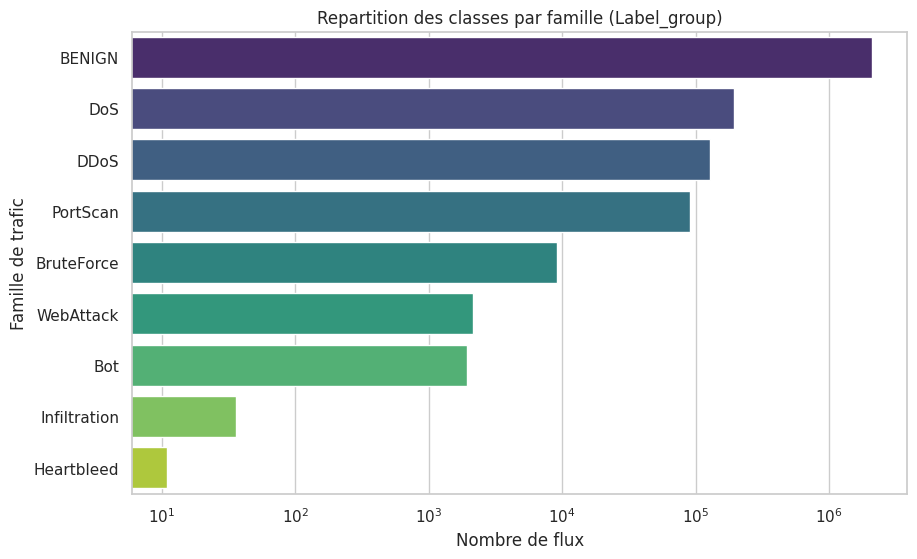

In [3]:
# 3. Repartition des classes Label_group (countplot trie)
ordre_group = df["Label_group"].value_counts().index

print("=== Repartition des classes Label_group ===")
print(df["Label_group"].value_counts())

plt.figure(figsize=(10, 6))
sns.countplot(data=df, y="Label_group", order=ordre_group, palette="viridis")
plt.title("Repartition des classes par famille (Label_group)")
plt.xlabel("Nombre de flux")
plt.ylabel("Famille de trafic")
# Echelle logarithmique car les classes rares (Heartbleed, Infiltration) sont ecrasees
plt.xscale("log")
plt.savefig(DOSSIER_FIGURES + "/01_repartition_labels.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Desequilibre binaire BENIGN vs attaque

Barplot des proportions de la cible Label_binary (0 = BENIGN, 1 = attaque).

=== Desequilibre binaire (Label_binary) ===
BENIGN  : 2095057 flux (83.1109 %)
Attaque : 425741 flux (16.8891 %)


/tmp/ipykernel_1197559/1525626896.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels_bin, y=prop_bin.values, palette=["#2c7fb8", "#d95f0e"])


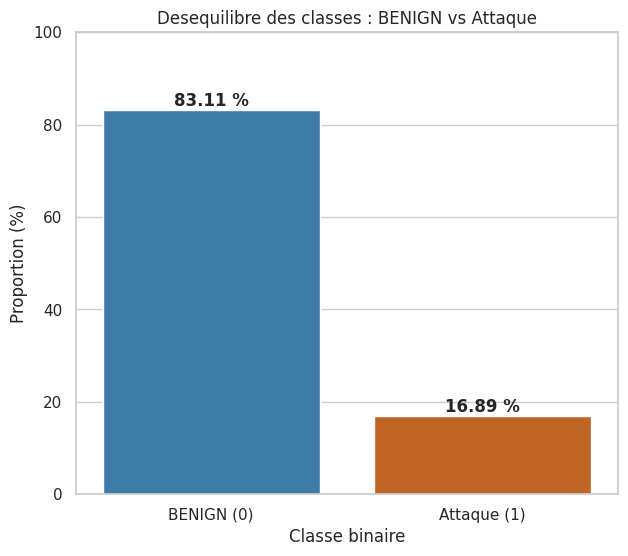

In [4]:
# 4. Desequilibre binaire : proportions BENIGN vs attaque
counts_bin = df["Label_binary"].value_counts().sort_index()
prop_bin = df["Label_binary"].value_counts(normalize=True).sort_index() * 100
labels_bin = ["BENIGN (0)", "Attaque (1)"]

print("=== Desequilibre binaire (Label_binary) ===")
print(f"BENIGN  : {counts_bin[0]} flux ({prop_bin[0]:.4f} %)")
print(f"Attaque : {counts_bin[1]} flux ({prop_bin[1]:.4f} %)")

plt.figure(figsize=(7, 6))
ax = sns.barplot(x=labels_bin, y=prop_bin.values, palette=["#2c7fb8", "#d95f0e"])
# Annotation des pourcentages au-dessus de chaque barre
for i, v in enumerate(prop_bin.values):
    ax.text(i, v + 1, f"{v:.2f} %", ha="center", fontweight="bold")
plt.title("Desequilibre des classes : BENIGN vs Attaque")
plt.xlabel("Classe binaire")
plt.ylabel("Proportion (%)")
plt.ylim(0, 100)
plt.savefig(DOSSIER_FIGURES + "/02_desequilibre_binaire.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Matrice de correlation des features numeriques

Heatmap des correlations de Pearson sur les 78 features. On echantillonne
150 000 lignes pour rester rapide. Pas d'annotations (trop de features).

=== Paires de features les plus correlees (|r| > 0.95) ===
Total Length of Fwd Packets  Subflow Fwd Bytes       1.000000
Bwd Packet Length Mean       Avg Bwd Segment Size    1.000000
RST Flag Count               ECE Flag Count          1.000000
Fwd Packet Length Mean       Avg Fwd Segment Size    1.000000
Total Backward Packets       Subflow Bwd Packets     1.000000
Fwd Header Length            Fwd Header Length.1     1.000000
Fwd URG Flags                CWE Flag Count          1.000000
Fwd PSH Flags                SYN Flag Count          1.000000
Total Fwd Packets            Subflow Fwd Packets     1.000000
Total Length of Bwd Packets  Subflow Bwd Bytes       1.000000
Fwd Header Length            min_seg_size_forward    1.000000
Fwd Header Length.1          min_seg_size_forward    1.000000
Total Backward Packets       Bwd Header Length       0.999922
Bwd Header Length            Subflow Bwd Packets     0.999922
Total Backward Packets       Subflow Fwd Packets     0.999607
dtype: floa

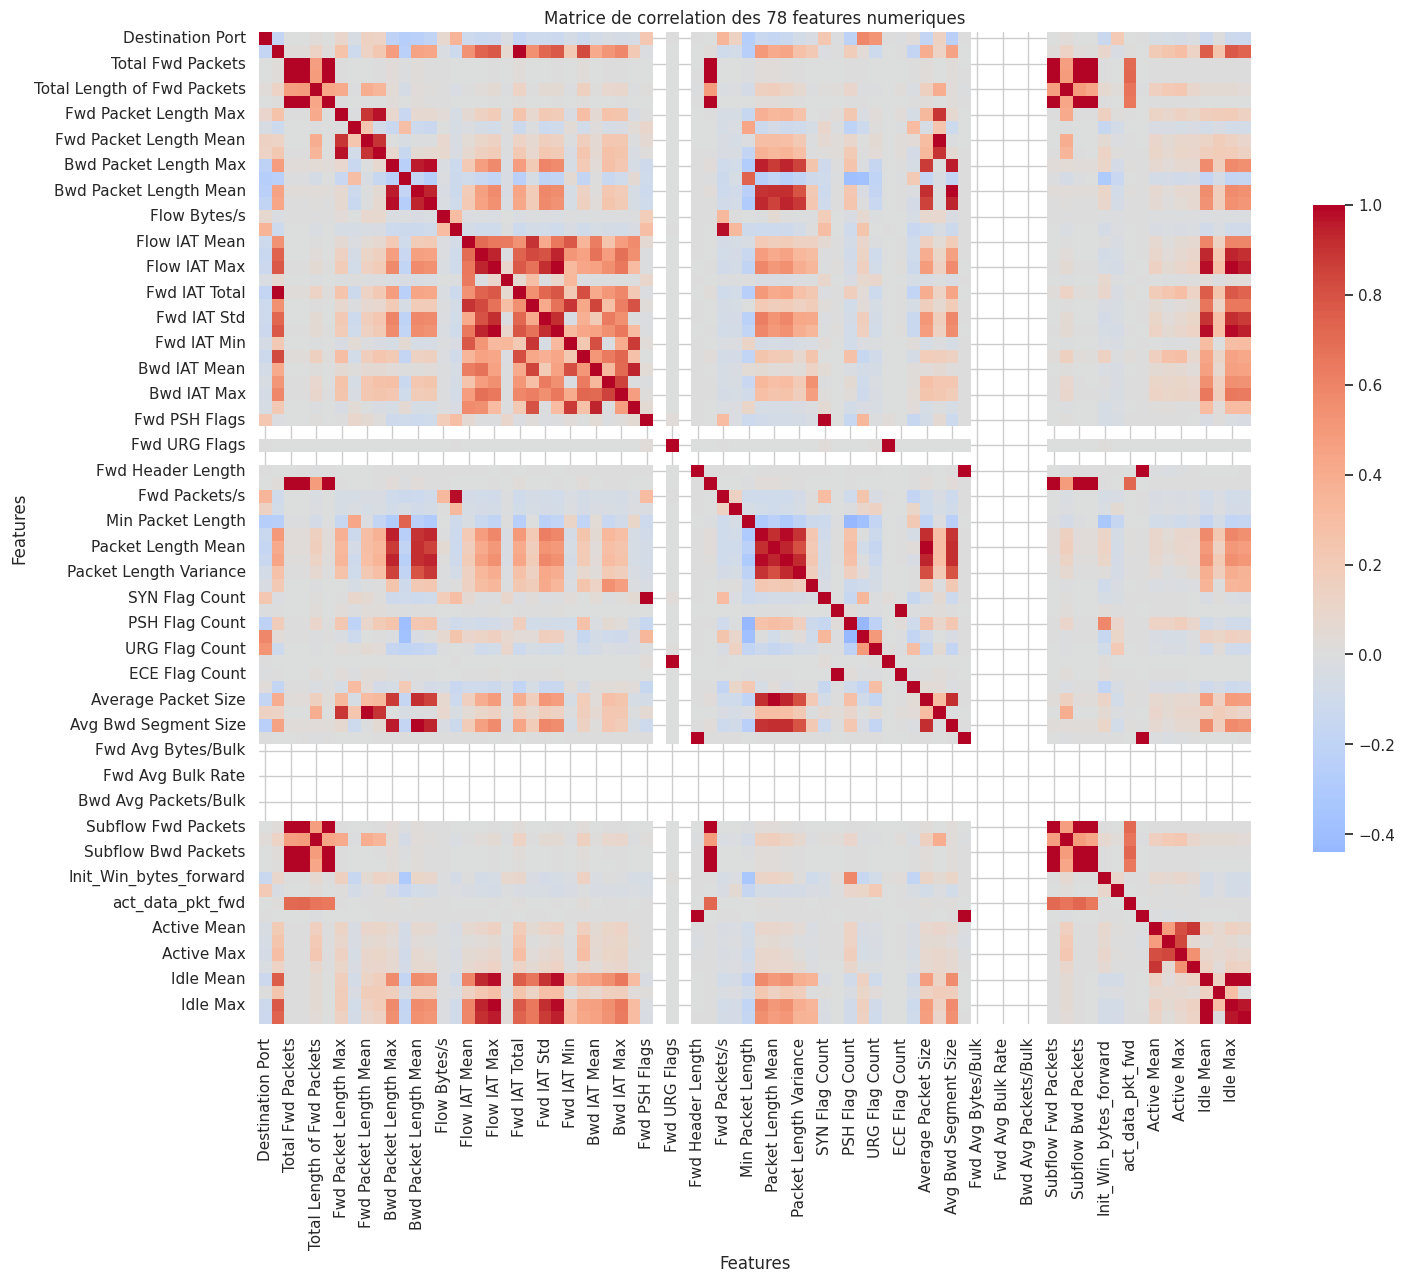

In [5]:
# 5. Matrice de correlation des features numeriques (sur echantillon)
df_sample = df.sample(150000, random_state=42)
corr = df_sample[features].corr()

# Reperage des paires de features fortement correlees (|corr| > 0.95)
corr_abs = corr.abs()
masque_haut = np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
paires_fortes = corr_abs.where(masque_haut).stack().sort_values(ascending=False)
print("=== Paires de features les plus correlees (|r| > 0.95) ===")
print(paires_fortes[paires_fortes > 0.95].head(15))

plt.figure(figsize=(16, 14))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.6})
plt.title("Matrice de correlation des 78 features numeriques")
plt.xlabel("Features")
plt.ylabel("Features")
plt.savefig(DOSSIER_FIGURES + "/03_correlation.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Distributions de features de flux discriminantes

Boxplots de 4 features de flux par classe binaire (BENIGN vs Attaque),
sur echantillon. Axe y en echelle logarithmique car les valeurs sont
tres etalees.

=== Statistiques des features discriminantes par classe ===
         Flow Duration  Flow Bytes/s  Total Fwd Packets  Fwd Packet Length Max
Classe                                                                        
Attaque      6055552.0    143.576630                4.0                   20.0
BENIGN         41207.0   4231.188477                2.0                   42.0


/tmp/ipykernel_1197559/504318815.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=serie, x="Classe", y=col, ax=axs[i], palette=["#2c7fb8", "#d95f0e"])
/tmp/ipykernel_1197559/504318815.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=serie, x="Classe", y=col, ax=axs[i], palette=["#2c7fb8", "#d95f0e"])
/tmp/ipykernel_1197559/504318815.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=serie, x="Classe", y=col, ax=axs[i], palette=["#2c7fb8", "#d95f0e"])


/tmp/ipykernel_1197559/504318815.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=serie, x="Classe", y=col, ax=axs[i], palette=["#2c7fb8", "#d95f0e"])


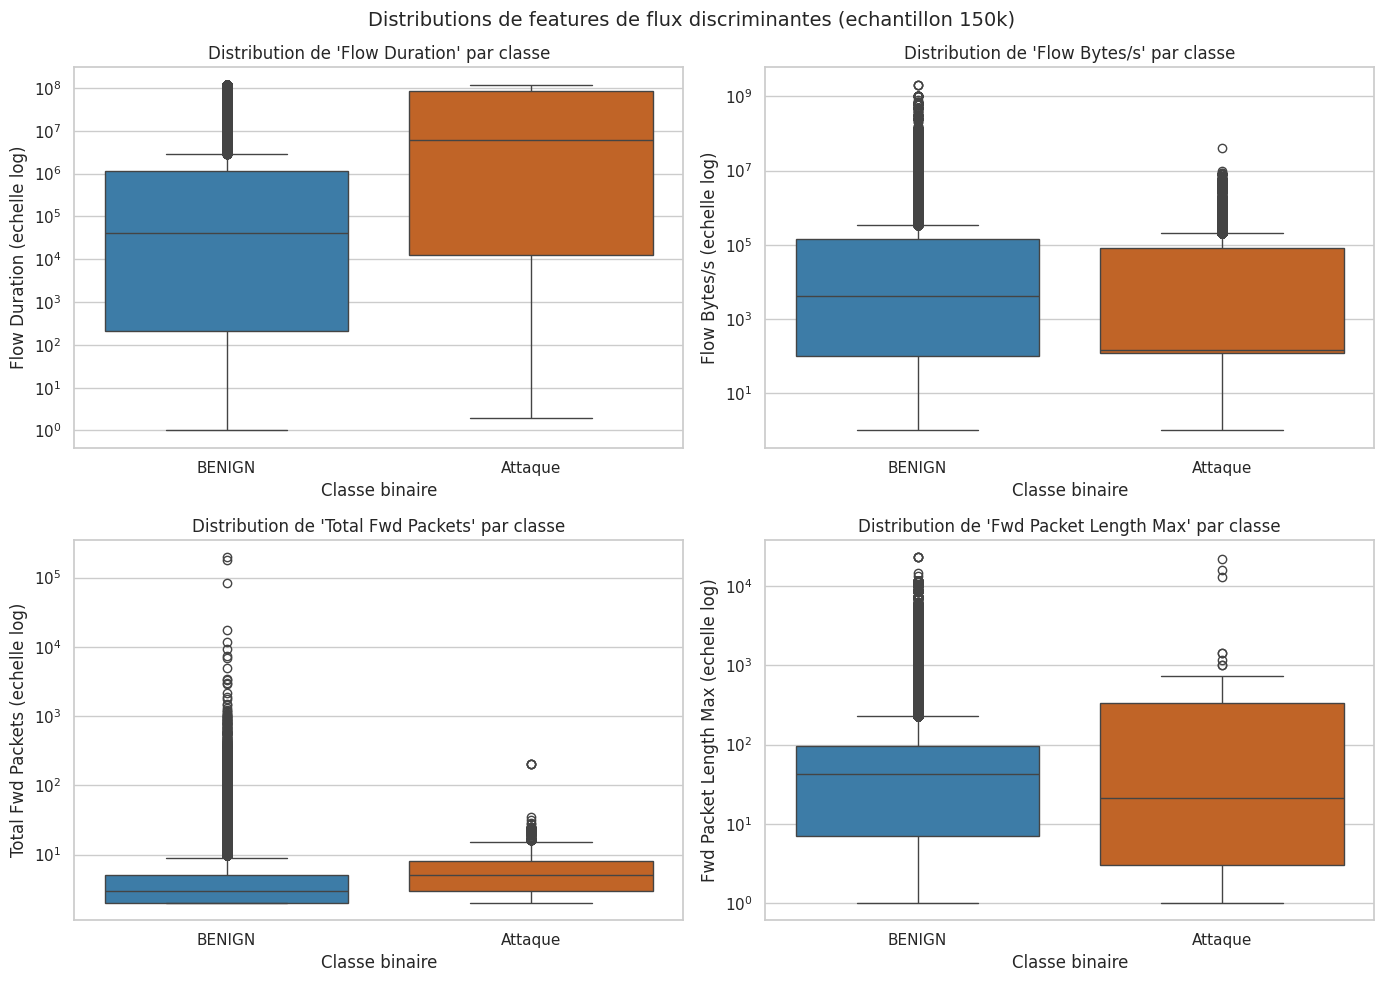

In [6]:
# 6. Distributions de 4 features discriminantes par classe binaire
features_distrib = ["Flow Duration", "Flow Bytes/s", "Total Fwd Packets", "Fwd Packet Length Max"]

# Copie de l'echantillon avec un libelle binaire lisible
df_box = df_sample[features_distrib + ["Label_binary"]].copy()
df_box["Classe"] = np.where(df_box["Label_binary"] == 0, "BENIGN", "Attaque")

print("=== Statistiques des features discriminantes par classe ===")
print(df_box.groupby("Classe")[features_distrib].median())

# Pour le log on travaille sur des valeurs positives (decalage de 1)
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.ravel()
for i, col in enumerate(features_distrib):
    serie = df_box.copy()
    serie[col] = serie[col].clip(lower=0) + 1
    sns.boxplot(data=serie, x="Classe", y=col, ax=axs[i], palette=["#2c7fb8", "#d95f0e"])
    axs[i].set_yscale("log")
    axs[i].set_title(f"Distribution de '{col}' par classe")
    axs[i].set_xlabel("Classe binaire")
    axs[i].set_ylabel(col + " (echelle log)")
plt.suptitle("Distributions de features de flux discriminantes (echantillon 150k)", fontsize=14)
plt.tight_layout()
plt.savefig(DOSSIER_FIGURES + "/04_distributions_features.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Heatmap des moyennes standardisees par famille d'attaque

On standardise (z-score) les features les plus variables, puis on calcule
leur moyenne par famille (Label_group). Cela revele quelles features
caracterisent chaque type d'attaque (signature).

=== Top 20 features qui differencient le plus les familles ===
Bwd Packet Length Mean              -> ecart inter-familles 1.1488
Avg Bwd Segment Size                -> ecart inter-familles 1.1488
Bwd Packet Length Std               -> ecart inter-familles 1.1225
Bwd Packet Length Max               -> ecart inter-familles 1.1095
Packet Length Std                   -> ecart inter-familles 1.0894
Average Packet Size                 -> ecart inter-familles 1.0765
Packet Length Mean                  -> ecart inter-familles 1.0619
Max Packet Length                   -> ecart inter-familles 1.0408
Idle Mean                           -> ecart inter-familles 1.0324
Idle Min                            -> ecart inter-familles 1.0304
Fwd IAT Std                         -> ecart inter-familles 1.0262
Idle Max                            -> ecart inter-familles 1.0190
Packet Length Variance              -> ecart inter-familles 1.0076
Init_Win_bytes_backward             -> ecart inter-familles 1.0054

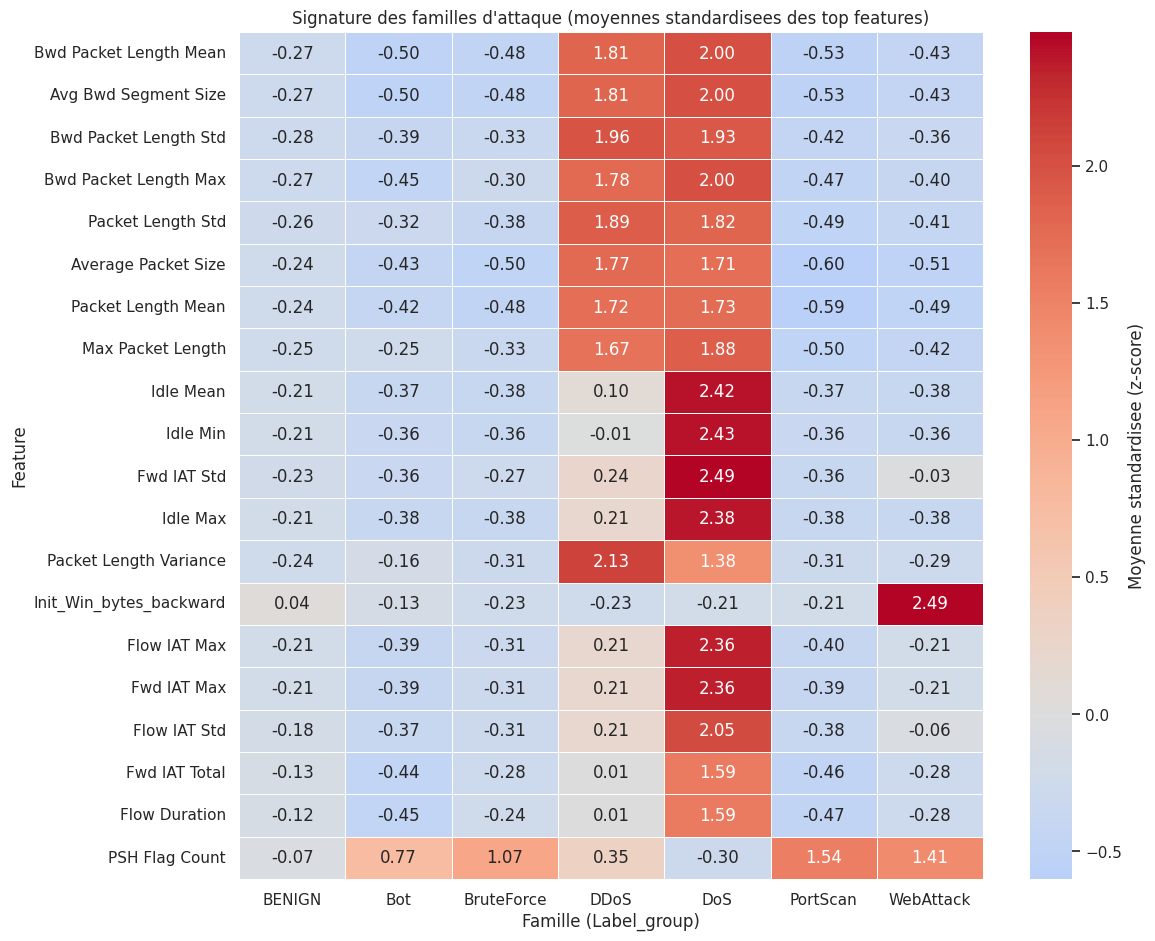

In [7]:
# 7. Selection des top features les plus discriminantes entre familles
# Standardisation z-score de toutes les features sur l'echantillon
moyennes = df_sample[features].mean()
ecarts = df_sample[features].std().replace(0, 1)  # eviter la division par zero
df_std = (df_sample[features] - moyennes) / ecarts
df_std["Label_group"] = df_sample["Label_group"].values

# Moyenne standardisee de chaque feature par famille
profil_groupes = df_std.groupby("Label_group")[features].mean()

# On garde les 20 features dont la moyenne varie le plus entre familles
variabilite = profil_groupes.std().sort_values(ascending=False)
top_features = variabilite.head(20).index.tolist()
print("=== Top 20 features qui differencient le plus les familles ===")
for f in top_features:
    print(f"{f:35s} -> ecart inter-familles {variabilite[f]:.4f}")

# Sous-matrice (familles x top features), transposee pour lecture verticale
heat = profil_groupes[top_features].T

plt.figure(figsize=(12, 11))
sns.heatmap(heat, cmap="coolwarm", center=0, annot=True, fmt=".2f",
            linewidths=0.5, cbar_kws={"label": "Moyenne standardisee (z-score)"})
plt.title("Signature des familles d'attaque (moyennes standardisees des top features)")
plt.xlabel("Famille (Label_group)")
plt.ylabel("Feature")
plt.savefig(DOSSIER_FIGURES + "/05_features_par_attaque.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Recapitulatif des figures sauvegardees

In [8]:
# 8. Verification que les 5 figures sont bien presentes sur le disque
fichiers_figures = sorted(os.listdir(DOSSIER_FIGURES))
print("=== Figures sauvegardees dans reports/figures ===")
for f in fichiers_figures:
    chemin = DOSSIER_FIGURES + "/" + f
    taille = os.path.getsize(chemin) / 1024
    print(f"{f:35s} -> {taille:.4f} Ko")

=== Figures sauvegardees dans reports/figures ===
01_repartition_labels.png           -> 35.7891 Ko
02_desequilibre_binaire.png         -> 29.4033 Ko
03_correlation.png                  -> 276.4980 Ko
04_distributions_features.png       -> 114.5479 Ko
05_features_par_attaque.png         -> 223.3789 Ko


## 9. Observations principales (resume EDA)

**1. Fort desequilibre des classes.** Le trafic est tres majoritairement
BENIGN (~83,1 %, soit 2 095 057 flux) contre ~16,9 % d'attaques
(425 741 flux). Au sein des attaques, les familles sont elles aussi
desequilibrees : DoS et DDoS dominent (193 745 et 128 014 flux), tandis
que Heartbleed (11) et Infiltration (36) sont quasi inexistantes. Il
faudra donc une strategie adaptee (stratify au split, `class_weight`,
voire sous-echantillonnage / SMOTE) pour ne pas ignorer les attaques rares.

**2. Features de flux discriminantes.** Les boxplots montrent que
'Flow Bytes/s', 'Flow Duration', 'Total Fwd Packets' et
'Fwd Packet Length Max' separent nettement BENIGN des attaques : les
attaques (DoS/DDoS notamment) presentent des debits et des volumes de
paquets atypiques. Ces variables seront de bons predicteurs pour les
modeles supervises et non supervises.

**3. Correlations fortes / redondance.** De nombreuses paires de features
sont quasi parfaitement correlees (|r| > 0,95), par construction du
dataset : par ex. 'Subflow Fwd Packets' ~ 'Total Fwd Packets',
'Fwd Header Length' ~ 'Fwd Header Length.1', les paires
Mean/Avg Segment Size et Packet Length Std/Variance. Cette redondance
justifiera plus tard une selection / reduction de features.

**4. Signatures par famille d'attaque.** La heatmap des moyennes
standardisees revele que chaque famille active un sous-ensemble de
features distinct : les attaques par debit (DoS/DDoS) se distinguent sur
les compteurs de paquets et de bytes, PortScan sur les flags et la duree
de flux, BruteForce/WebAttack sur les longueurs de paquets. Ces
signatures rendent la detection explicable plausible (top features par
alerte).

**5. Donnees propres et exploitables.** Le dataset gele ne contient plus
aucun NaN ni Infinity et toutes les features sont numeriques, ce qui
permet de passer directement a la modelisation (baseline de regles,
Isolation Forest puis Random Forest).